# Weeks 10 & 11 — Matplotlib & Seaborn Homework

*Chhiring Lama*  
**Created:** 2025-10-30

---


## Introduction

In this project, I explore how the use of social media — measured as *daily screen time* — might be linked to mental health, particularly **stress levels**.  
My main goal is to understand whether people who spend more time on social media tend to report higher stress, or if there’s no clear relationship.

The dataset I’m using is titled **“Mental Health and Social Media”**, which I downloaded from Kaggle.  Source citation is included in the Data Exploration.
It contains self-reported information such as daily screen time, stress levels, sleep quality, and happiness index. For this assignment, I focus only on two key columns:

- **`Daily_Screen_Time(hrs)`** – the average number of hours a person spends on social media per day  
- **`stress_level(1_10)`** – the individual’s reported stress level on a scale of 1 (low stress) to 10 (high stress)

I chose this dataset because I’m personally curious about the **impact of social media on society**, especially on mental health.  
With the rise of digital communication and constant online engagement, I want to see if data supports the common perception that **increased social media use might correlate with higher stress**.

This analysis will not prove causation — it only explores associations or trends in the available data.  
I’ll use simple data-cleaning steps and visualizations (using Matplotlib and Seaborn) to see if any clear pattern emerges.


## Data Exploration
I pushed the dataset to my own github repository and loaded to jupytor notebook.
Data source: https://www.kaggle.com/datasets/prince7489/mental-health-and-social-media-balance-dataset/data

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

# Load data
url = "https://media.githubusercontent.com/media/topkelama/lfsStorage/refs/heads/main/Mental_Health_and_Social_Mediat.csv"
df = pd.read_csv(url)

# Ensure no duplicate-named columns (defensive)
df = df.loc[:, ~df.columns.duplicated()].copy()

print("Columns in dataset:")
print(df.columns.tolist())
display(df.head())
df.info()


Columns in dataset:
['User_ID', 'Age', 'Gender', 'Daily_Screen_Time(hrs)', 'Sleep_Quality(1-10)', 'Stress_Level(1-10)', 'Days_Without_Social_Media', 'Exercise_Frequency(week)', 'Social_Media_Platform', 'Happiness_Index(1-10)']


,User_ID,Age,Gender,Daily_Screen_Time(hrs),Sleep_Quality(1-10),Stress_Level(1-10),Days_Without_Social_Media,Exercise_Frequency(week),Social_Media_Platform,Happiness_Index(1-10)
0,U001,44,Male,3.1,7,6,2,5.0,Facebook,10
1,U002,30,Other,5.1,7,8,5,3.0,LinkedIn,10
2,U003,23,Other,7.4,6,7,1,3.0,YouTube,6
3,U004,36,Female,5.7,7,8,1,1.0,TikTok,8
4,U005,34,Female,7,4,7,5,1.0,X (Twitter),8


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   User_ID                    500 non-null    object 
 1   Age                        500 non-null    int64  
 2   Gender                     500 non-null    object 
 3   Daily_Screen_Time(hrs)     500 non-null    object 
 4   Sleep_Quality(1-10)        500 non-null    int64  
 5   Stress_Level(1-10)         497 non-null    object 
 6   Days_Without_Social_Media  500 non-null    int64  
 7   Exercise_Frequency(week)   495 non-null    float64
 8   Social_Media_Platform      500 non-null    object 
 9   Happiness_Index(1-10)      500 non-null    int64  
dtypes: float64(1), int64(4), object(5)
memory usage: 39.2+ KB


## Data Wrangling

- Use the exact column names from the file (with a tiny fallback for capitalization).
- Convert both columns to numeric.
- Fill missing values with the column mean.
- Create a simple `usage_group` (Low / Moderate / High) from screen time.


In [8]:

#  This is just to make sure the column name is eactly as it appeared in the dataframe.
#if not go with the lower case version

if 'Daily_Screen_Time(hrs)' in df.columns:
    screen_col = 'Daily_Screen_Time(hrs)'
elif 'daily_screen_time(hrs)' in df.columns:
    screen_col = 'daily_screen_time(hrs)'
else:
    raise KeyError("Could not find 'Daily_Screen_Time(hrs)' in columns: " + str(df.columns.tolist())) # converts list to readable text

if 'Stress_Level(1-10)' in df.columns:
    stress_col = 'Stress_Level(1-10)'
elif 'stress_Level(1-10)' in df.columns:
    stress_col = 'stress_Level(1_10)'
else:
    raise KeyError("Could not find 'stress_level(1_10)' in columns: " + str(df.columns.tolist()))

# --- MINIMAL CLEANUP ---
df = df.copy()
df[screen_col] = pd.to_numeric(df[screen_col], errors='coerce') # if finds non numeric values,then fill with NAN
df[stress_col] = pd.to_numeric(df[stress_col], errors='coerce')

# fill missing values (NaN) with the average of each column
df[screen_col].fillna(df[screen_col].mean(), inplace=True) 
df[stress_col].fillna(df[stress_col].mean(), inplace=True)

# divide screen time into 3 equal groups: Low, Moderate, High
q = df[screen_col].quantile([0.33, 0.66])      # find 33% and 66% percentile cut points
df['usage_group'] = pd.cut(                    # create a new categorical column
    df[screen_col],                             # use screen time column to group
    bins=[-np.inf, q.iloc[0], q.iloc[1], np.inf],     # ([-infinity, 33%], [33%, 66%], [66%, infinity]
    labels=['Low','Moderate','High']
)

print("Using columns -> screen:", screen_col, "| stress:", stress_col)
display(df[[screen_col, stress_col, 'usage_group']].head())


Using columns -> screen: Daily_Screen_Time(hrs) | stress: Stress_Level(1-10)


,Daily_Screen_Time(hrs),Stress_Level(1-10),usage_group
0,3.1,6.0,Low
1,5.1,8.0,Moderate
2,7.4,7.0,High
3,5.7,8.0,Moderate
4,7.0,7.0,High


## Visualization — Part 1 (Matplotlib)
I make three simple plots and describe what they show.

### Plot 1: Daily Screen Time Trend (by record index)

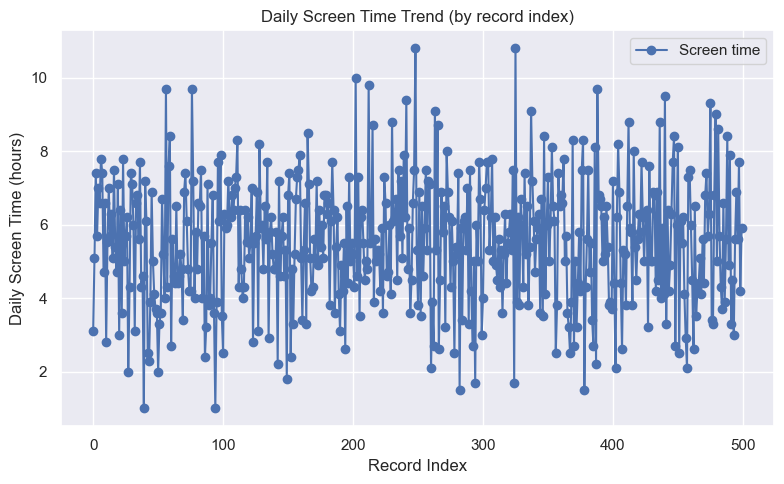

Interpretation: If the line generally rises, I treat that as a spike in screen time across the records.


In [4]:

plt.figure(figsize=(8,5))
plt.plot(df.index, df[screen_col], marker='o', linewidth=1.5, label='Screen time')
plt.title('Daily Screen Time Trend (by record index)')
plt.xlabel('Record Index'); plt.ylabel('Daily Screen Time (hours)')
plt.legend(loc='best')
plt.tight_layout(); plt.show()

print("Interpretation: If the line generally rises, I treat that as a spike in screen time across the records.")


### Plot 2: Stress vs Daily Screen Time (scatter + simple fit)

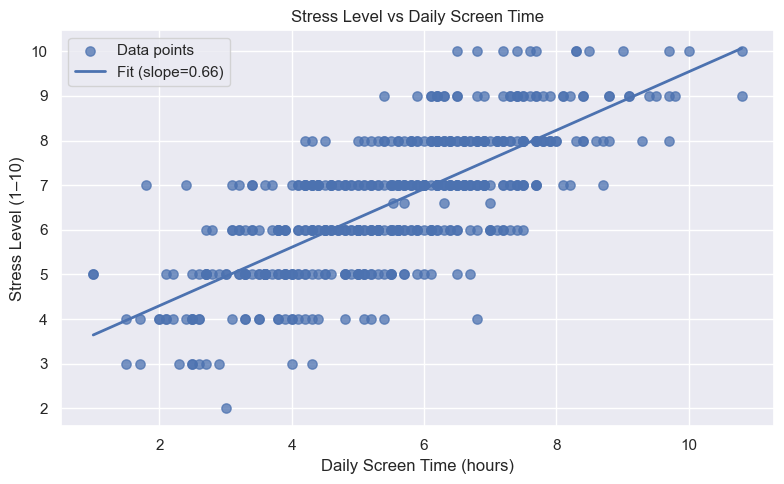

Pearson correlation: 0.7401513493873151
Interpretation: Positive slope/correlation means higher screen time aligns with higher stress (association, not cause).


In [5]:

x = df[screen_col]; y = df[stress_col]

plt.figure(figsize=(8,5))
plt.scatter(x, y, s=45, alpha=0.75, label='Data points')

# Draw a simple linear fit if there is variation
if x.nunique() > 1 and y.nunique() > 1:
    m, b = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 100)
    plt.plot(xs, m*xs + b, linewidth=2, label=f'Fit (slope={m:.2f})')

plt.title('Stress Level vs Daily Screen Time')
plt.xlabel('Daily Screen Time (hours)'); plt.ylabel('Stress Level (1–10)')
plt.legend(loc='best')
plt.tight_layout(); plt.show()

print('Pearson correlation:', float(np.corrcoef(x, y)[0,1]))
print("Interpretation: Positive slope/correlation means higher screen time aligns with higher stress (association, not cause).")


### Plot 3: Average Stress by Usage Group

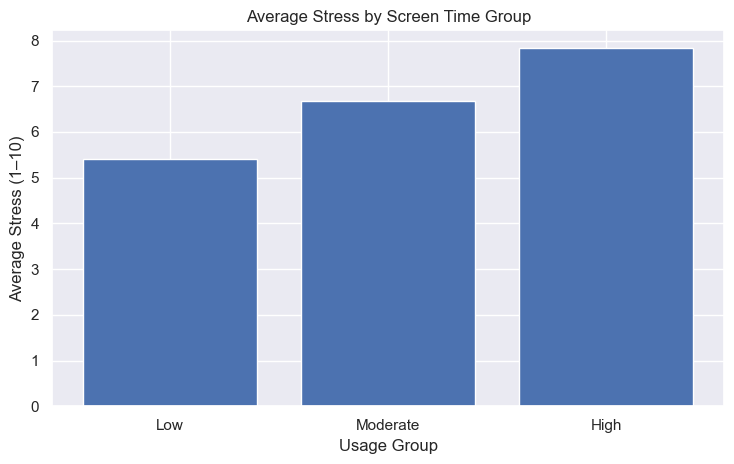

,avg_stress
usage_group,
Low,5.408046
Moderate,6.675772
High,7.830919


Interpretation: If High > Moderate > Low, heavier use aligns with more stress on average.


In [6]:

group_avg = df.groupby('usage_group')[stress_col].mean()

plt.figure(figsize=(7.5,4.8))
plt.bar(group_avg.index.astype(str), group_avg.values)
plt.title('Average Stress by Screen Time Group')
plt.xlabel('Usage Group'); plt.ylabel('Average Stress (1–10)')
plt.tight_layout(); plt.show()

display(group_avg.to_frame('avg_stress'))
print("Interpretation: If High > Moderate > Low, heavier use aligns with more stress on average.")


## Visualization — Part 2 (Seaborn)
I recreate two visuals using Seaborn to confirm the same patterns.

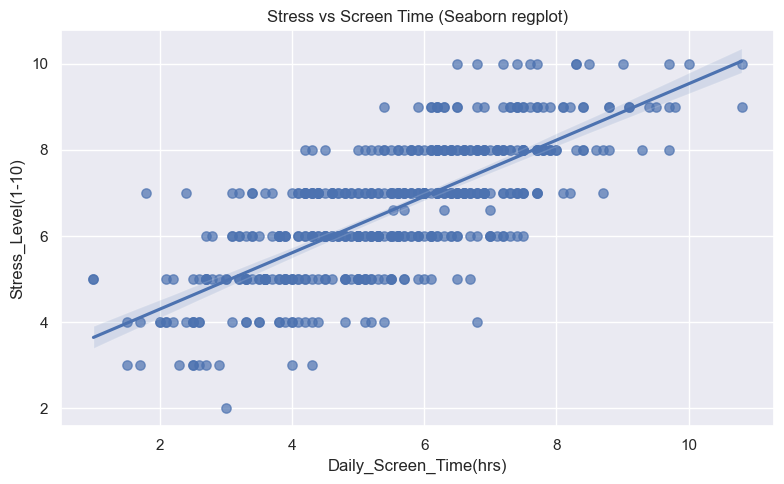

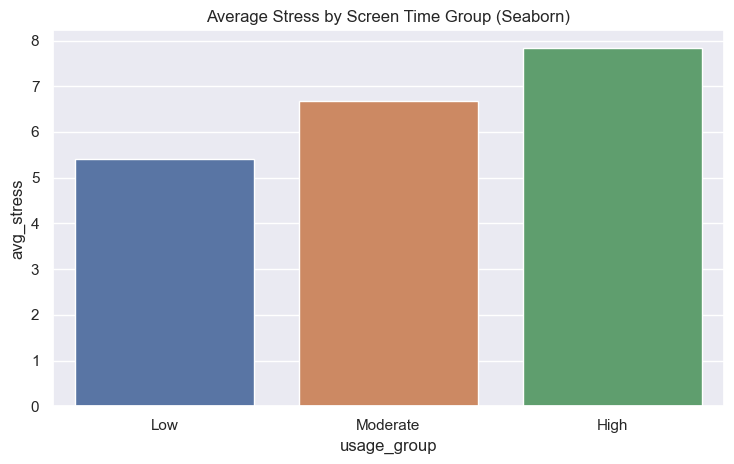

In [7]:

plt.figure(figsize=(8,5))
sns.regplot(x=screen_col, y=stress_col, data=df, scatter_kws={'alpha':0.7, 's':45})
plt.title('Stress vs Screen Time (Seaborn regplot)')
plt.tight_layout(); plt.show()

avg_df = group_avg.reset_index().rename(columns={stress_col:'avg_stress'})
plt.figure(figsize=(7.5,4.8))
sns.barplot(data=avg_df, x='usage_group', y='avg_stress', order=['Low','Moderate','High'])
plt.title('Average Stress by Screen Time Group (Seaborn)')
plt.tight_layout(); plt.show()


## Visualization — Part 3 (Comparison)

- **Matplotlib**: more manual control (markers, legends, labels), good when I want to customize details.  
- **Seaborn**: nicer defaults and quick regression helpers, good for fast checks.  

Both told the same story here.


## Conclusion

After analyzing the data, I found some noticeable patterns:

- **Screen time tends to increase** across records, which may reflect how people’s time on social media has been rising in general.  
- There appears to be a **positive relationship between daily screen time and stress level** — as screen time increases, reported stress also rises.  
- When dividing users into three groups (Low, Moderate, and High screen time), the **High usage group consistently showed higher average stress** compared to the other two groups.

These findings suggest that **heavy social media use may be associated with higher stress**, though this is only correlation, not causation.  
Other factors like sleep quality, lifestyle, or personality could also play major roles.

Overall, the analysis supports the idea that increased social media engagement can have a measurable impact on mental well-being.  
This kind of data exploration helps raise awareness about how online habits might influence emotional health — and reminds us to use digital platforms more mindfully.